In [21]:
!pip install -q numpyro@git+https://github.com/pyro-ppl/numpyro

/Users/thomaspinder/Library/Application Support/hatch/pythons/3.12/python/lib/python3.12/pty.py:95: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


# Composing Gaussian Processes with NumPyro using GPJax

[GPJax](https://docs.jaxgaussianprocesses.com/) is a Gaussian process library built on JAX and Flax NNX. In this notebook, we use GPJax’s GP components inside a NumPyro model and run MCMC over everything jointly — regression coefficients and GP hyperparameters alike.

The model is a semiparametric spatial regression:

$$y(\mathbf{x}) = \underbrace{\mathbf{w}^\top \mathbf{x} + b}_{\text{linear trend}} + \underbrace{f(\mathbf{x})}_{\text{GP residual}} + \epsilon$$

NumPyro handles the linear part. GPJax handles the GP. NUTS samples from the joint posterior.

In [22]:
from functools import partial

import gpjax as gpx
from gpjax.numpyro_extras import register_parameters
import matplotlib as mpl
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
import jax.random as jr

import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, Predictive

jax.config.update("jax_enable_x64", True)
assert numpyro.__version__.startswith("0.20.1")

## Data simulation

We generate 200 points on a $[0, 5] \times [0, 5]$ grid. The true signal has two parts: a linear trend $y_{\text{lin}} = 2x_1 - x_2 + 1.5$ and a nonlinear residual $y_{\text{res}} = \sin(x_1)\cos(x_2)$, plus Gaussian noise $\epsilon \sim \mathcal{N}(0, 0.1^2)$.

In [23]:
N = 200
key = jr.key(123)
keys = jr.split(key, 8)

X = jr.uniform(keys[0], shape=(N, 2), minval=0.0, maxval=5.0)

# True generative components
true_slope = jnp.array([2.0, -1.0])
true_intercept = 1.5
y_lin = X @ true_slope + true_intercept
y_res = jnp.sin(X[:, 0]) * jnp.cos(X[:, 1])

latent_signal = y_lin + y_res
noise_stddev = 0.1
y = latent_signal + noise_stddev * jr.normal(keys[1], shape=latent_signal.shape)

## Building the GP with GPJax

GPJax kernels bundle a covariance function with its hyperparameters — the same Matérn or RBF functions you’d write by hand, but with parameter management built in.

Each hyperparameter lives in a `PositiveReal` (or similar) container that enforces positivity via a softplus bijection. The part that matters for NumPyro: these containers can hold a **prior distribution**. When we call `register_parameters` later, any parameter with a prior becomes a `numpyro.sample` site automatically.

A GP in GPJax is assembled by multiplying a `Prior` (kernel + mean function) by a `Likelihood` to get a `Posterior` that can compute marginal log-likelihoods and predictions.

In [24]:
lengthscale = gpx.parameters.PositiveReal(1.0, prior=dist.LogNormal(0.0, 1.0))
variance = gpx.parameters.PositiveReal(1.0, prior=dist.LogNormal(0.0, 1.0))

kernel = gpx.kernels.Matern32(
    active_dims=[0, 1], lengthscale=lengthscale, variance=variance
)
meanf = gpx.mean_functions.Constant()
gp_prior = gpx.gps.Prior(mean_function=meanf, kernel=kernel)

obs_stddev = gpx.parameters.NonNegativeReal(0.1, prior=dist.LogNormal(0.0, 1.0))
likelihood = gpx.likelihoods.Gaussian(num_datapoints=N, obs_stddev=obs_stddev)
gp_posterior = gp_prior * likelihood

## The joint NumPyro model

The model below mixes ordinary NumPyro sampling with GPJax’s GP. The bridge between the two libraries is `register_parameters`: it walks the GPJax posterior, finds every parameter that carries a prior, and registers each one as a `numpyro.sample` site. The returned GPJax object has its parameter values controlled by NumPyro’s sampler.

We compute the GP’s marginal log-likelihood on the residuals (observations minus linear trend) and add it to the model’s log-density with `numpyro.factor`. No `plate` is needed here — the GP marginal likelihood already accounts for all observations in a single scalar.

For predictions, `p_posterior.predict(X_new, train_data=D_resid)` gives the GP’s predictive distribution at new locations. The total prediction is the linear trend plus the GP mean.

In [25]:
def joint_model(X, Y, gp_posterior, X_new=None):
    # Linear trend parameters (standard NumPyro)
    slope = numpyro.sample("slope", dist.Normal(0.0, 5.0).expand([2]))
    intercept = numpyro.sample("intercept", dist.Normal(0.0, 5.0))

    trend = X @ slope + intercept

    # Register GPJax parameters as NumPyro sample sites
    p_posterior = register_parameters(gp_posterior)

    if Y is not None:
        residuals = (Y - trend).reshape(-1, 1)
        D_resid = gpx.Dataset(X=X, y=residuals)
        mll = gpx.objectives.conjugate_mll(p_posterior, D_resid)
        numpyro.factor("gp_log_lik", mll)

    if X_new is not None and Y is not None:
        residuals = (Y - trend).reshape(-1, 1)
        D_resid = gpx.Dataset(X=X, y=residuals)

        latent_dist = p_posterior.predict(X_new, train_data=D_resid)
        f_new = numpyro.sample("f_new", latent_dist).reshape((-1, 1))

        total_prediction = (X_new @ slope + intercept).reshape(-1, 1) + f_new
        numpyro.deterministic("y_pred", total_prediction)

## MCMC inference

NUTS samples from the joint posterior over the linear parameters and the GP hyperparameters.

In [26]:
joint_model_wrapper = partial(joint_model, gp_posterior=gp_posterior)
nuts_kernel = NUTS(joint_model_wrapper)
mcmc = MCMC(nuts_kernel, num_warmup=1500, num_samples=2000, num_chains=1)
mcmc.run(keys[2], X, y)
mcmc.print_summary()

sample: 100%|██████████| 3500/3500 [00:26<00:00, 132.70it/s, 15 steps of size 2.35e-01. acc. prob=0.93]


                                mean       std    median      5.0%     95.0%     n_eff     r_hat
                 intercept      1.70      1.19      1.72     -0.14      3.75   1030.02      1.00
     likelihood.obs_stddev      0.11      0.01      0.11      0.10      0.12   1786.87      1.00
  prior.kernel.lengthscale      4.31      1.19      4.14      2.37      6.07    558.78      1.00
     prior.kernel.variance      1.84      1.52      1.41      0.26      3.68    579.57      1.00
                  slope[0]      1.82      0.22      1.83      1.49      2.19   1355.69      1.00
                  slope[1]     -0.98      0.21     -0.98     -1.30     -0.63   1237.23      1.00

Number of divergences: 0


### Inspecting the samples

Let's take a look at the posterior samples for the linear coefficients and the GP hyperparameters. We can use `arviz` to visualize the trace and summary statistics.

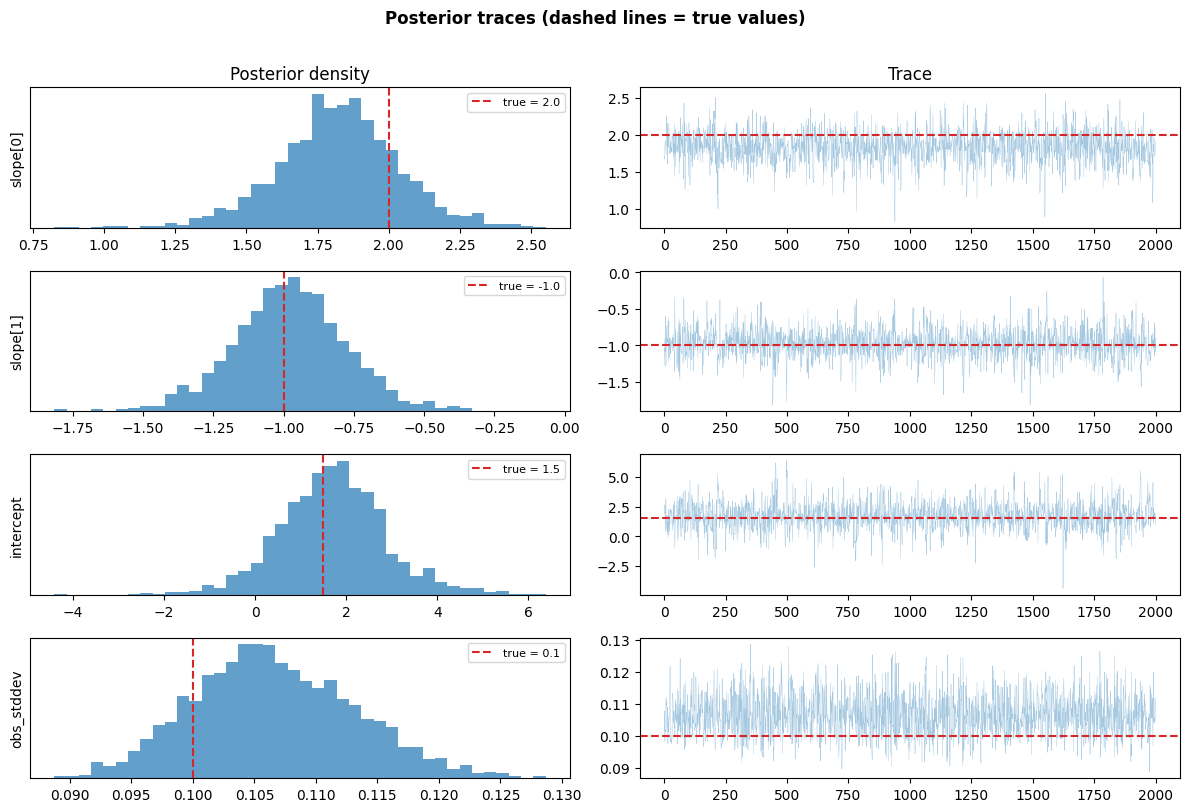

In [31]:
samples = mcmc.get_samples()

param_info = [
    ("slope[0]", samples["slope"][:, 0], true_slope[0]),
    ("slope[1]", samples["slope"][:, 1], true_slope[1]),
    ("intercept", samples["intercept"], true_intercept),
    ("obs_stddev", samples["likelihood.obs_stddev"], noise_stddev),
]

n_params = len(param_info)
fig, axes = plt.subplots(n_params, 2, figsize=(12, 2 * n_params))

for i, (name, chain, true_val) in enumerate(param_info):
    axes[i, 0].hist(
        chain, bins=40, density=True, alpha=0.7, color="C0", edgecolor="none"
    )
    if true_val is not None:
        axes[i, 0].axvline(
            true_val, color="C3", ls="--", lw=1.5, label=f"true = {true_val}"
        )
        axes[i, 0].legend(fontsize=8)
    axes[i, 0].set_ylabel(name, fontsize=10)
    axes[i, 0].set_yticks([])

    axes[i, 1].plot(chain, alpha=0.4, color="C0", lw=0.3)
    if true_val is not None:
        axes[i, 1].axhline(true_val, color="C3", ls="--", lw=1.5)

axes[0, 0].set_title("Posterior density")
axes[0, 1].set_title("Trace")
fig.suptitle("Posterior traces (dashed lines = true values)", fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()

## Posterior predictions

`Predictive` generates predictions for each posterior sample, combining the linear trend with the GP residual.

In [28]:
samples = mcmc.get_samples()
predictive = Predictive(joint_model_wrapper, samples, return_sites=["y_pred"])
preds = predictive(keys[3], X=X, Y=y, X_new=X)["y_pred"]
mean_pred = jnp.mean(preds, axis=0)

rmse = jnp.sqrt(jnp.mean((mean_pred.flatten() - latent_signal.flatten()) ** 2))
print(f"Joint Model RMSE (vs true signal): {rmse:.4f}")

Joint Model RMSE (vs true signal): 0.0450


## Visualisation

True signal vs. the joint model’s posterior mean on a 2D grid.

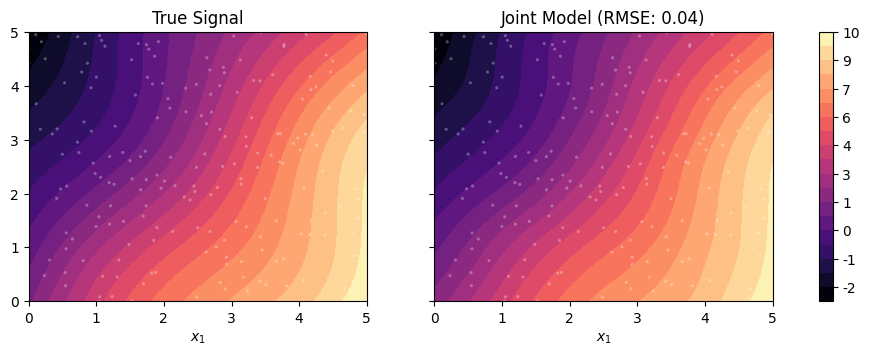

In [29]:
n_grid = 30
x1 = jnp.linspace(0, 5, n_grid)
x2 = jnp.linspace(0, 5, n_grid)
X1, X2 = jnp.meshgrid(x1, x2)
X_grid = jnp.column_stack([X1.ravel(), X2.ravel()])

y_grid_true = (X_grid @ true_slope + true_intercept) + (
    jnp.sin(X_grid[:, 0]) * jnp.cos(X_grid[:, 1])
)

preds_grid = predictive(keys[4], X=X, Y=y, X_new=X_grid)["y_pred"]
mean_pred_grid = jnp.mean(preds_grid, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5), sharey=True)

vmin = min(y_grid_true.min(), mean_pred_grid.min())
vmax = max(y_grid_true.max(), mean_pred_grid.max())
levels = jnp.linspace(vmin, vmax, 20)

axes[0].tricontourf(
    X_grid[:, 0], X_grid[:, 1], y_grid_true, levels=levels, cmap="magma"
)
axes[0].set_title("True Signal")

axes[1].tricontourf(
    X_grid[:, 0],
    X_grid[:, 1],
    mean_pred_grid.flatten(),
    levels=levels,
    cmap="magma",
)
axes[1].set_title(f"Joint Model (RMSE: {rmse:.2f})")

fig.colorbar(
    axes[0].collections[0],
    ax=axes.tolist(),
    format=mpl.ticker.FormatStrFormatter("%d"),
)

for ax in axes:
    ax.set_xlabel("$x_1$")
    ax.scatter(X[:, 0], X[:, 1], c="white", s=5, alpha=0.3, edgecolors="none")